In [42]:
import numpy as np
import pandas as pd
from pathlib import Path
import xgboost
from sklearn.model_selection import StratifiedKFold

TRAINPATH = Path.cwd() / "data/train.csv"
TESTPATH = Path.cwd() / "data/test.csv"
SUBMISSIONPATH = Path.cwd() / "data/sample_submission.csv"

if TRAINPATH.exists():
    print("EXISTS")

EXISTS


In [43]:
#First lets get into the train dataset and check what we can do (feature engineering and etc)

train_csv = pd.read_csv(TRAINPATH)
test_csv = pd.read_csv(TESTPATH)

print(train_csv.head(10))



   id   age  daily_screen_time_hours  social_media_hours  gaming_hours  \
0   0  24.0                      NaN                1.83          1.59   
1   1  19.0                     5.97                1.08           NaN   
2   2  18.0                     5.09                 NaN           NaN   
3   3  21.0                     6.42                1.26          1.42   
4   4  26.0                    11.20                1.87          2.81   
5   5  28.0                     7.37                1.78          1.56   
6   6  18.0                     4.24                1.61          1.14   
7   7  25.0                    10.79                3.92          2.48   
8   8  26.0                     8.42                2.57          3.41   
9   9  20.0                     8.74                1.40          2.43   

   work_study_hours  sleep_hours  notifications_per_day  app_opens_per_day  \
0              2.11         7.46                  122.0               38.0   
1              3.03         8

In [44]:
#GRAPHS
import matplotlib.pyplot as plt
def check_NaN_values(df : pd.DataFrame):

    n = len(df.columns)
    ncols = 3
    nrows = int(n/ncols) + 1

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*nrows, 10*ncols))
    axes = axes.flatten()
    for i, col in enumerate(df.columns):
        notnans = df[col].notna().sum()
        nans = df[col].isna().sum()
        axes[i].bar(["NOTNANS", "NANS"],[notnans, nans], color=["green", "red"])
        axes[i].set_title(f"{col}")

    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.show()

def check_hist_data(df : pd.DataFrame):
    n = len(df.columns)
    ncols = 3
    nrows = int(n/ncols) + 1
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*nrows, 10*ncols))
    axes = axes.flatten()

    for i, col in enumerate(df.select_dtypes(exclude="object")):
        axes[i].hist(df[col], bins=30)
        axes[i].set_title(f"{col}")

    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    plt.show()

def check_boxplot_data(df : pd.DataFrame):
    
    this_df = df.copy()
    this_df = this_df.drop("id", axis=1)
    this_df.boxplot(rot=45)
    plt.title("boxplot")
    plt.show()


In [45]:
#FEATURE ENGINEERING

def feature_changes(df : pd.DataFrame):

    this_df = df.copy()

    for col in this_df.columns:
        this_df[f"is_missing_{col}"] = this_df[col].isna().astype(int)
            
    this_df["difference_from_rec_sleep"] = abs(this_df["sleep_hours"] - 8.0) # the recommended sleep hours is 8h.
    this_df["missing_labels"] = this_df.isna().sum(axis=1)

    this_df["other_screen"] = (this_df['daily_screen_time_hours'] - 
                               (this_df['gaming_hours'] + 
                                this_df['social_media_hours'] + 
                                this_df['work_study_hours']))
    this_df["other_screen"] = this_df["other_screen"].clip(lower=0)
    


    
    conditions = [
        this_df['sleep_hours'] < 7,
        (this_df['sleep_hours'] >= 7) & (this_df['sleep_hours'] <= 9),
        this_df['sleep_hours'] > 9
    ]
    choices = [
        "Short", "Normal", "Long"
    ]

    this_df['sleep_type'] = np.select(conditions, choices, default="Unknown")



    for col in this_df.select_dtypes(include="object"):
        this_df[col] = this_df[col].astype("category")

    return this_df

    



In [46]:

from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import train_test_split

sk = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgboost_params = {
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [5, 6, 7, 8],
    "subsample": [0.5, 0.6, 0.7, 0.8],
    "max_leaves": [5, 7, 9, 10],
    "gamma": [0, 0.1, 0.3, 0.5],
    "min_child_weight": [1, 3, 5, 7],
    "scale_pos_weight": [1, 2, 3, 5]
}



xg_model = xgboost.XGBClassifier(
    n_estimators= 5000,
    objective='binary:logistic',
    tree_method='hist',
    enable_categorical=True,
    random_state=42,
    n_jobs=1
    )

from sklearn.model_selection import RandomizedSearchCV

search = RandomizedSearchCV( xg_model, xgboost_params, n_iter=10, scoring="f1", n_jobs=-1, random_state=42)

def train(df: pd.DataFrame):
    df = df.copy()

    check_NaN_values(df)
    check_hist_data(df)
    X, y = df.drop(["id", "addicted_label"], axis=1), df["addicted_label"]

    X = feature_changes(X)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    search.fit(X_train, y_train)

    model = search.best_estimator_
    best_params = search.best_params_
    print(best_params)

    return model

def predict(df : pd.DataFrame, model):
    df = df.copy()

    check_NaN_values(df)
    check_hist_data(df)
    X, id = df.drop("id", axis=1), df["id"]
    X = feature_changes(X)


    y_preds = model.predict(X)

    submission = pd.DataFrame({
        "id": id,
        "addicted_label": y_preds
    })

    submission.to_csv(SUBMISSIONPATH, index=False)

    print(f"SUBMITTED TO {SUBMISSIONPATH}")






    


    







        




    
        




    

    






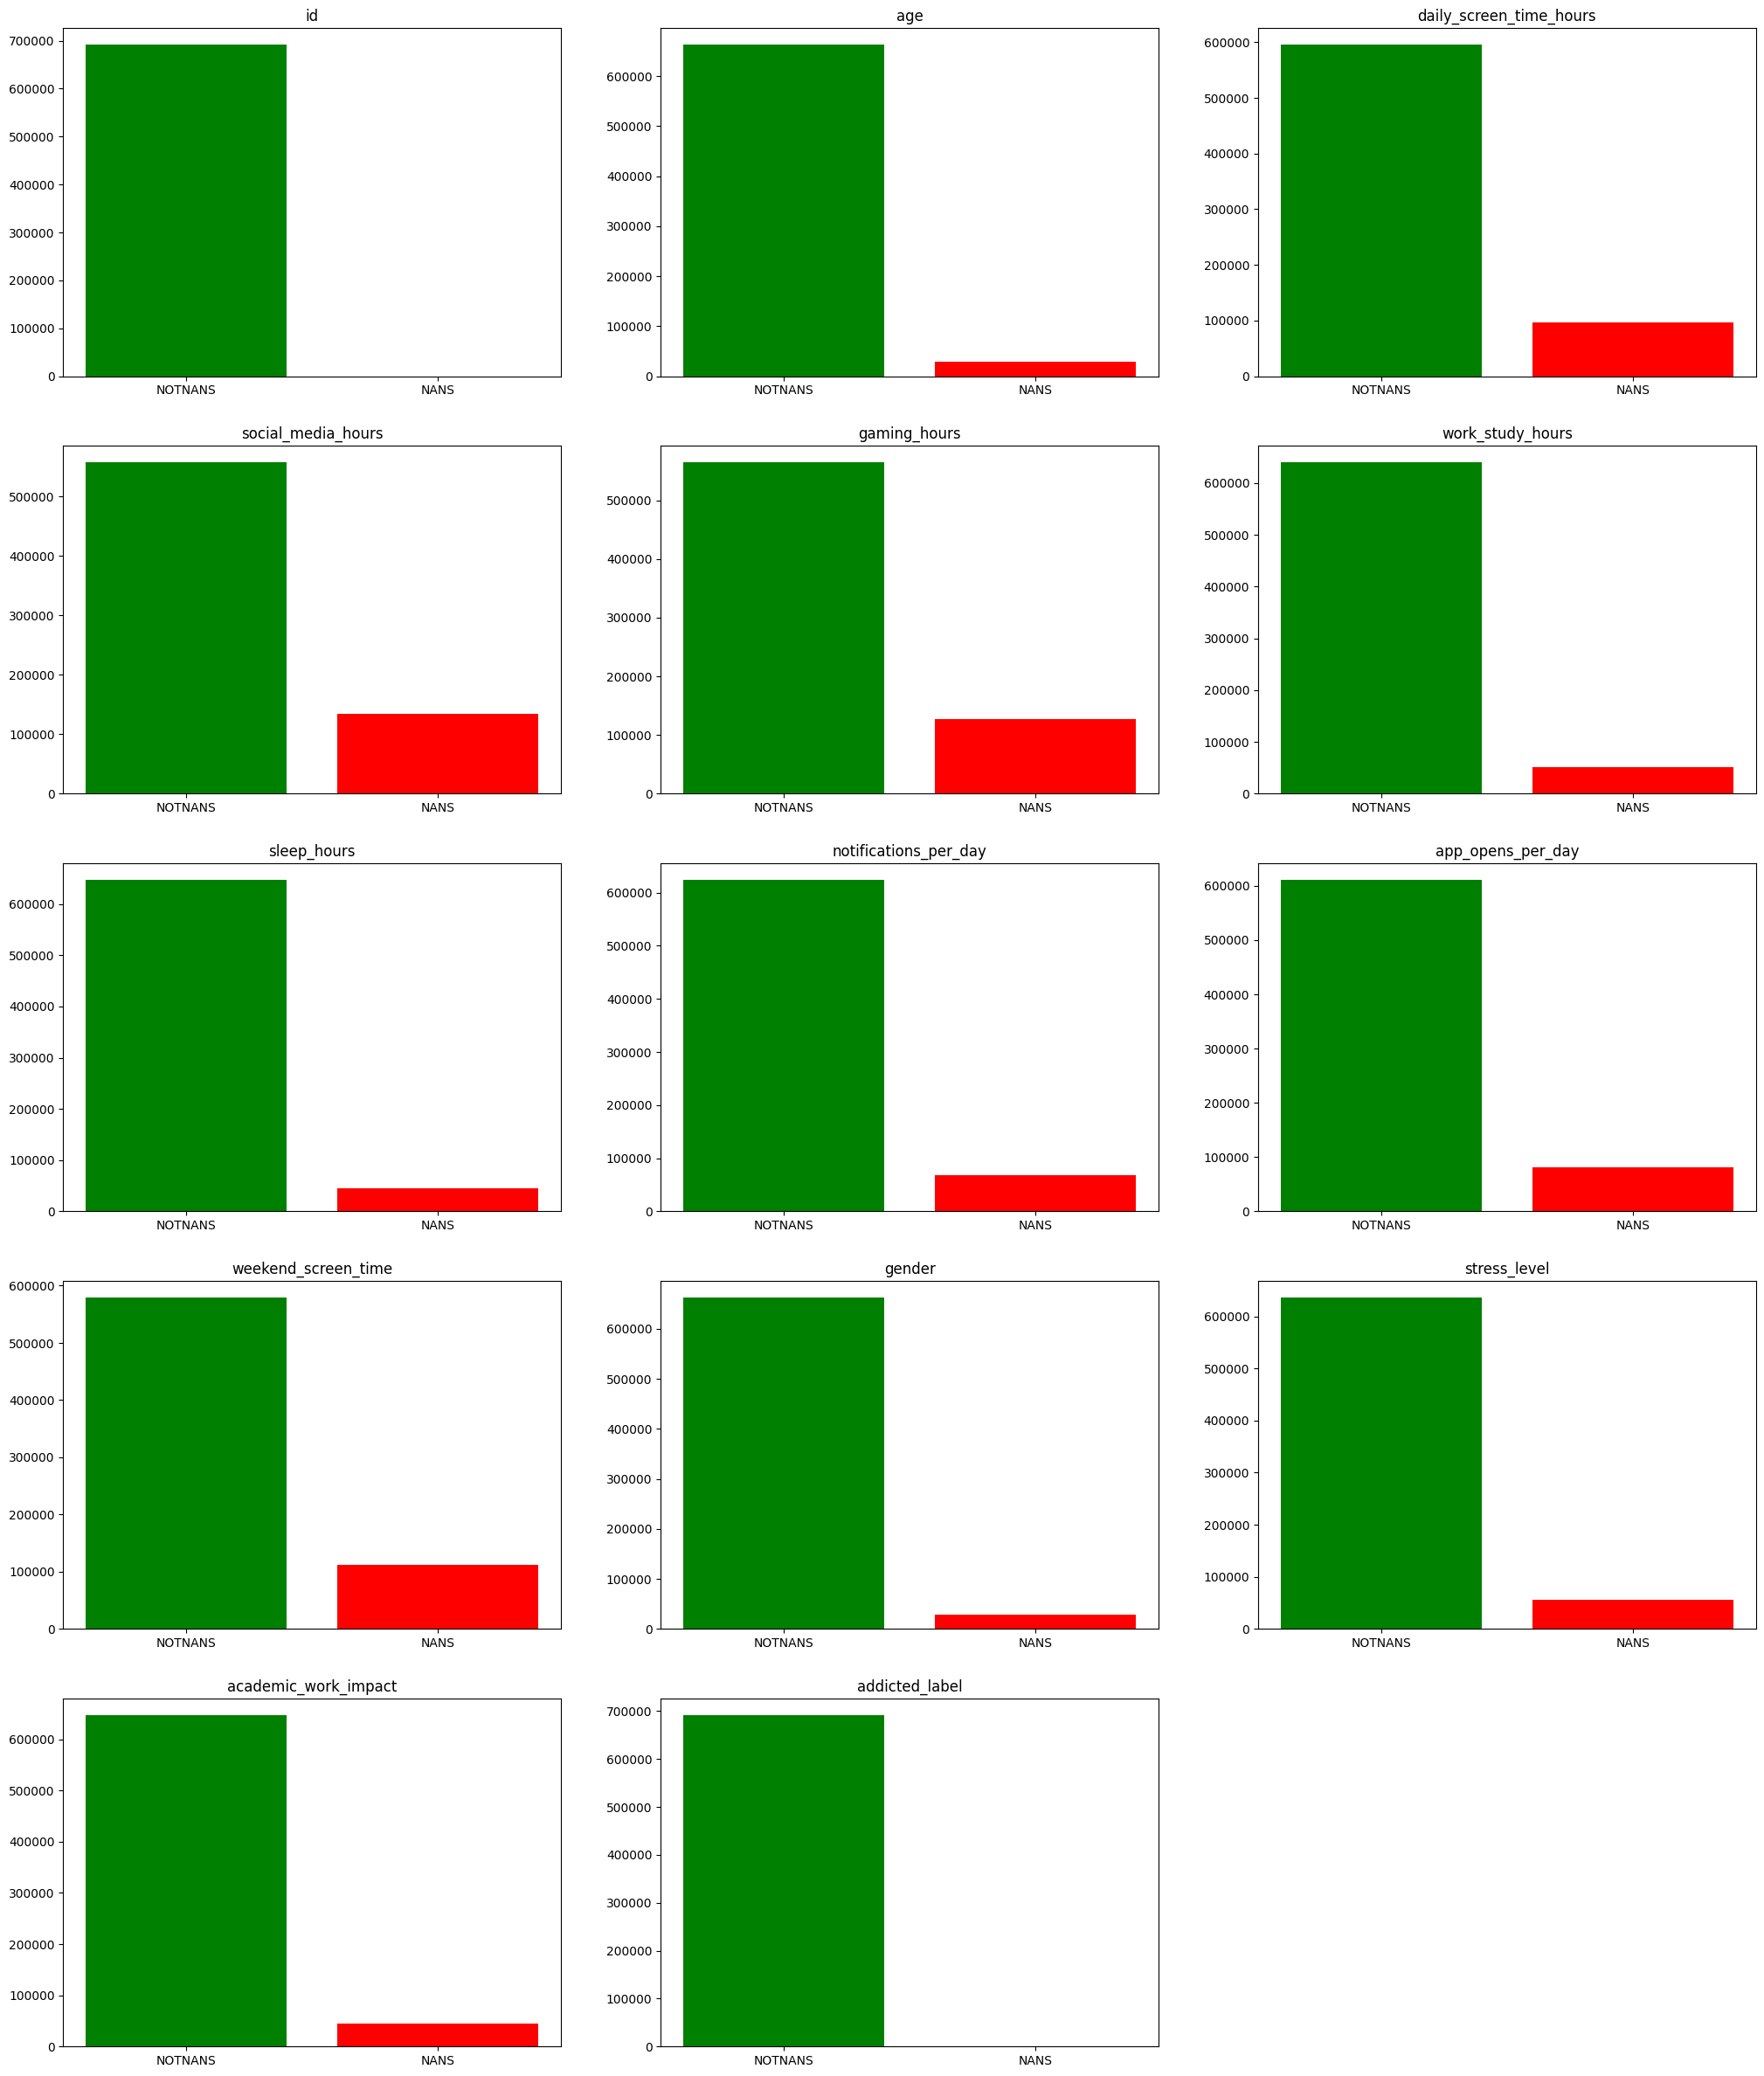

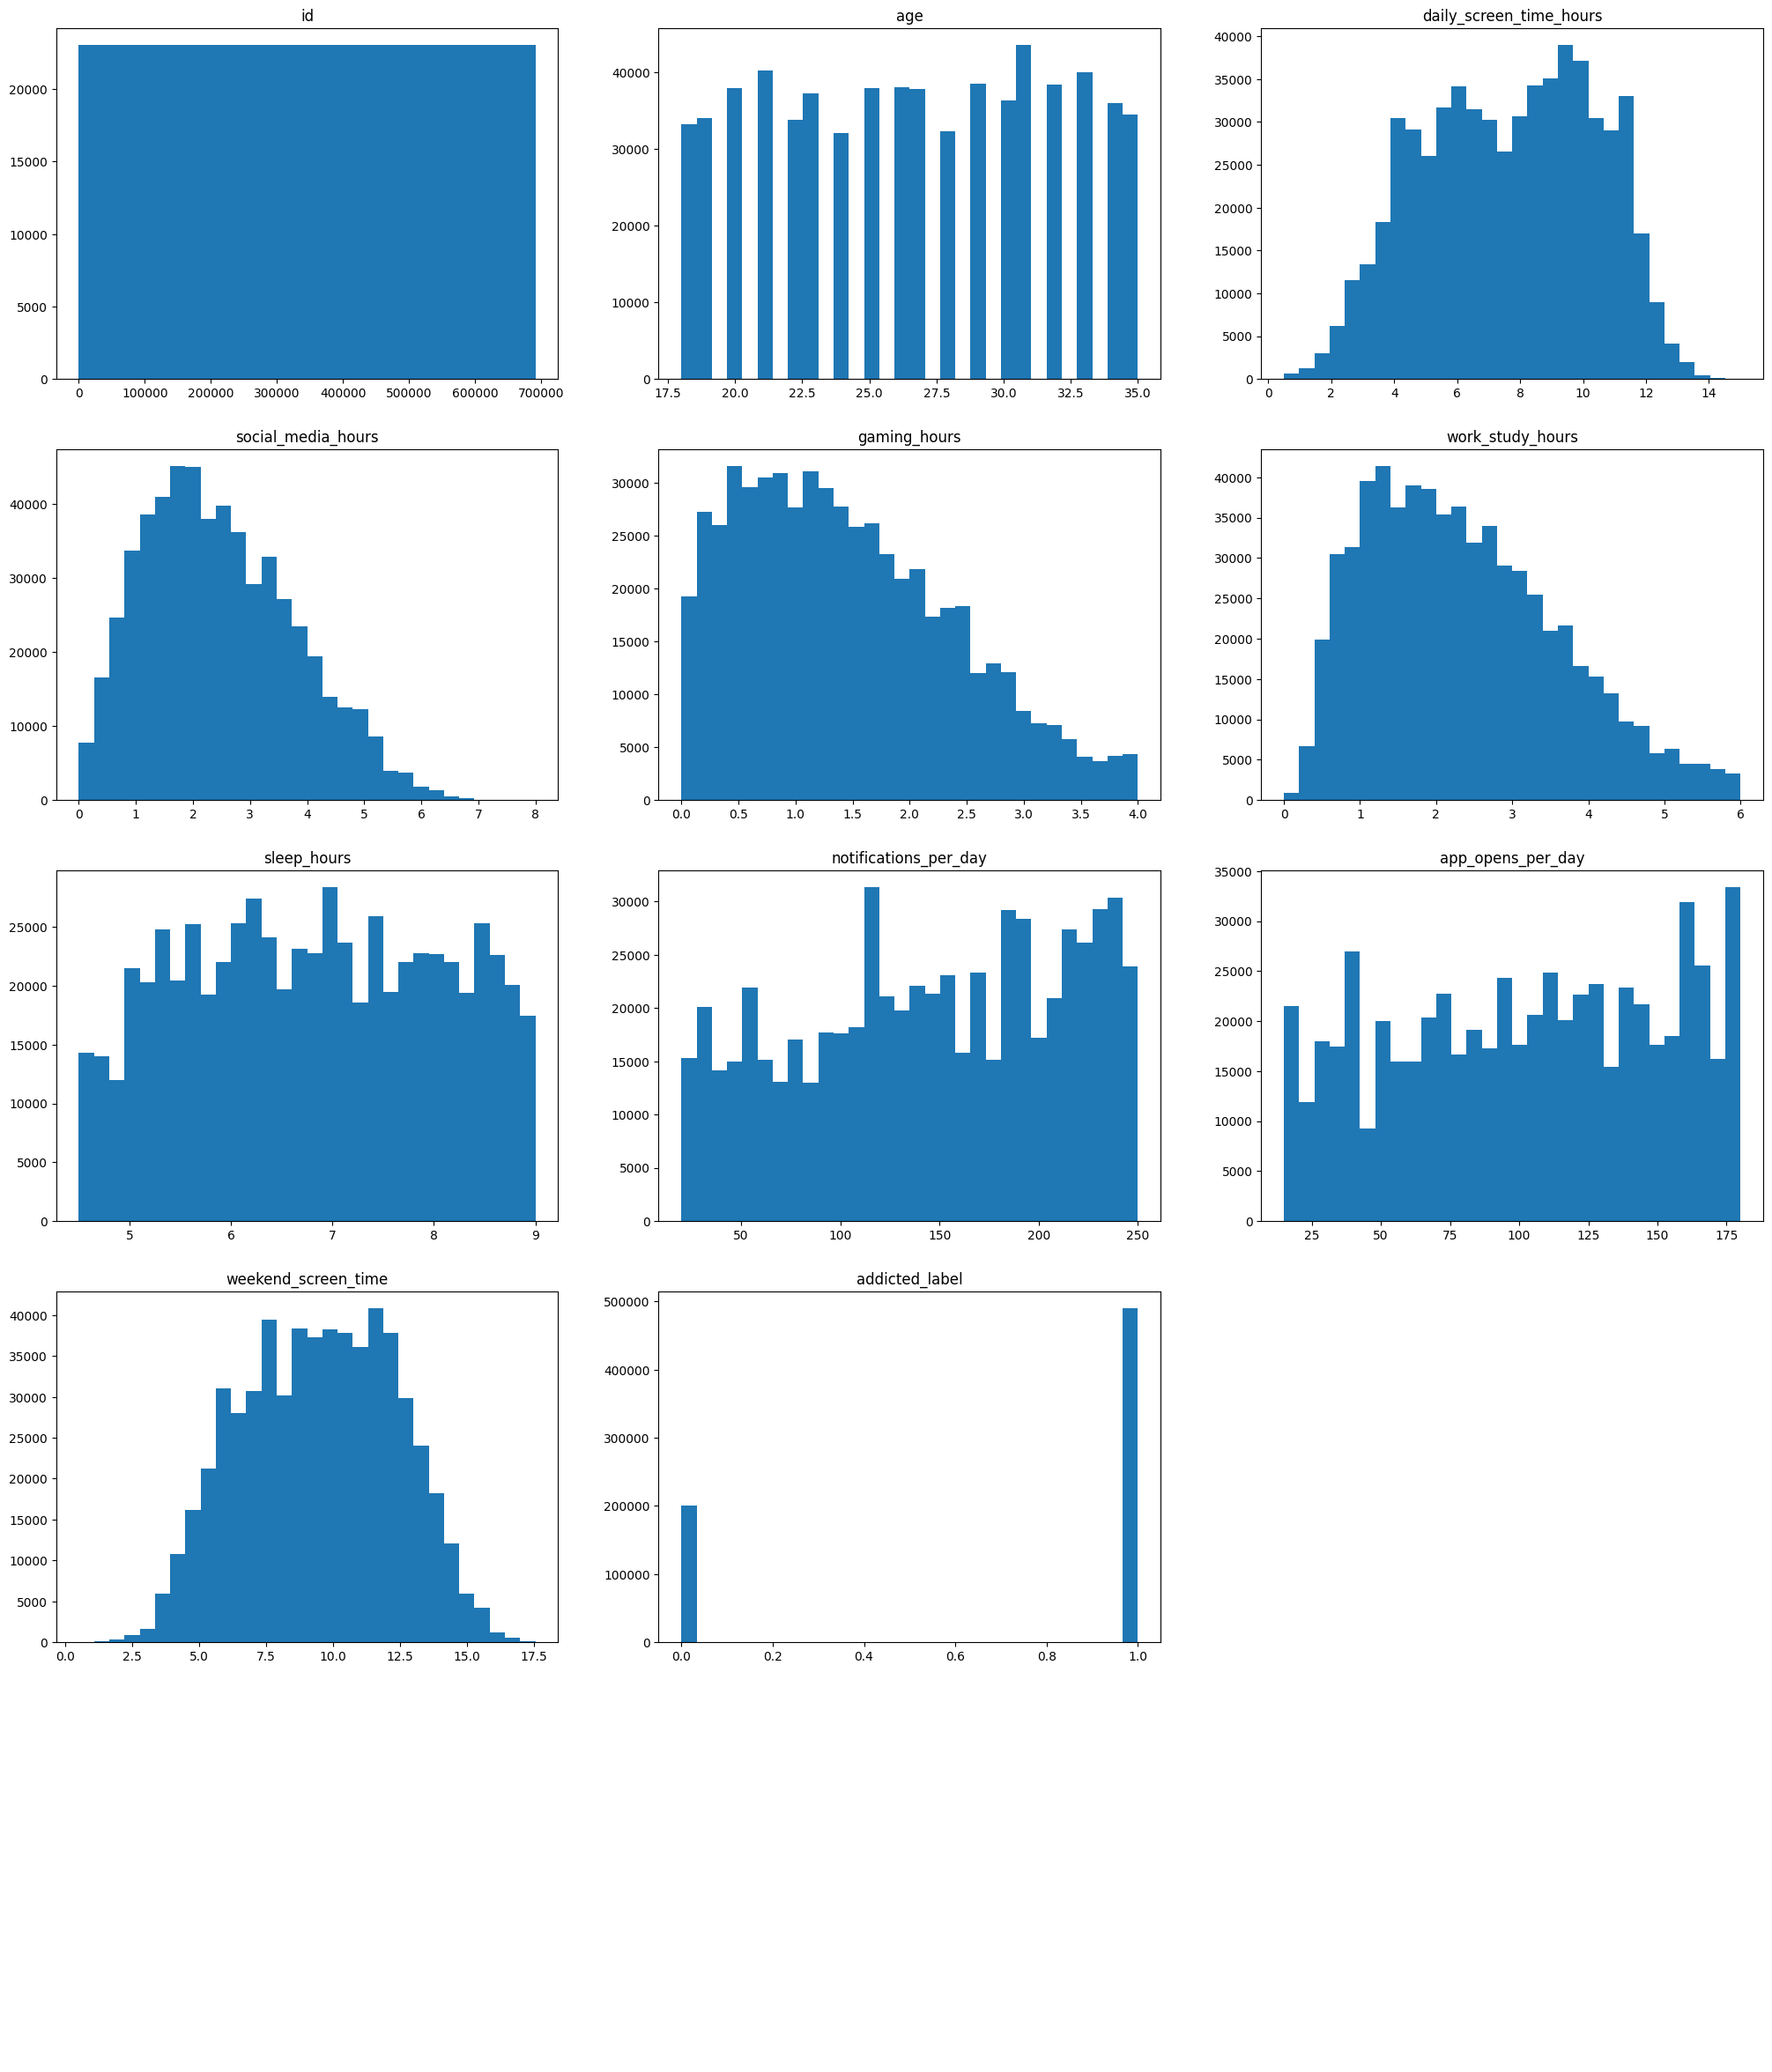

{'subsample': 0.8, 'scale_pos_weight': 1, 'min_child_weight': 7, 'max_leaves': 9, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0.5}


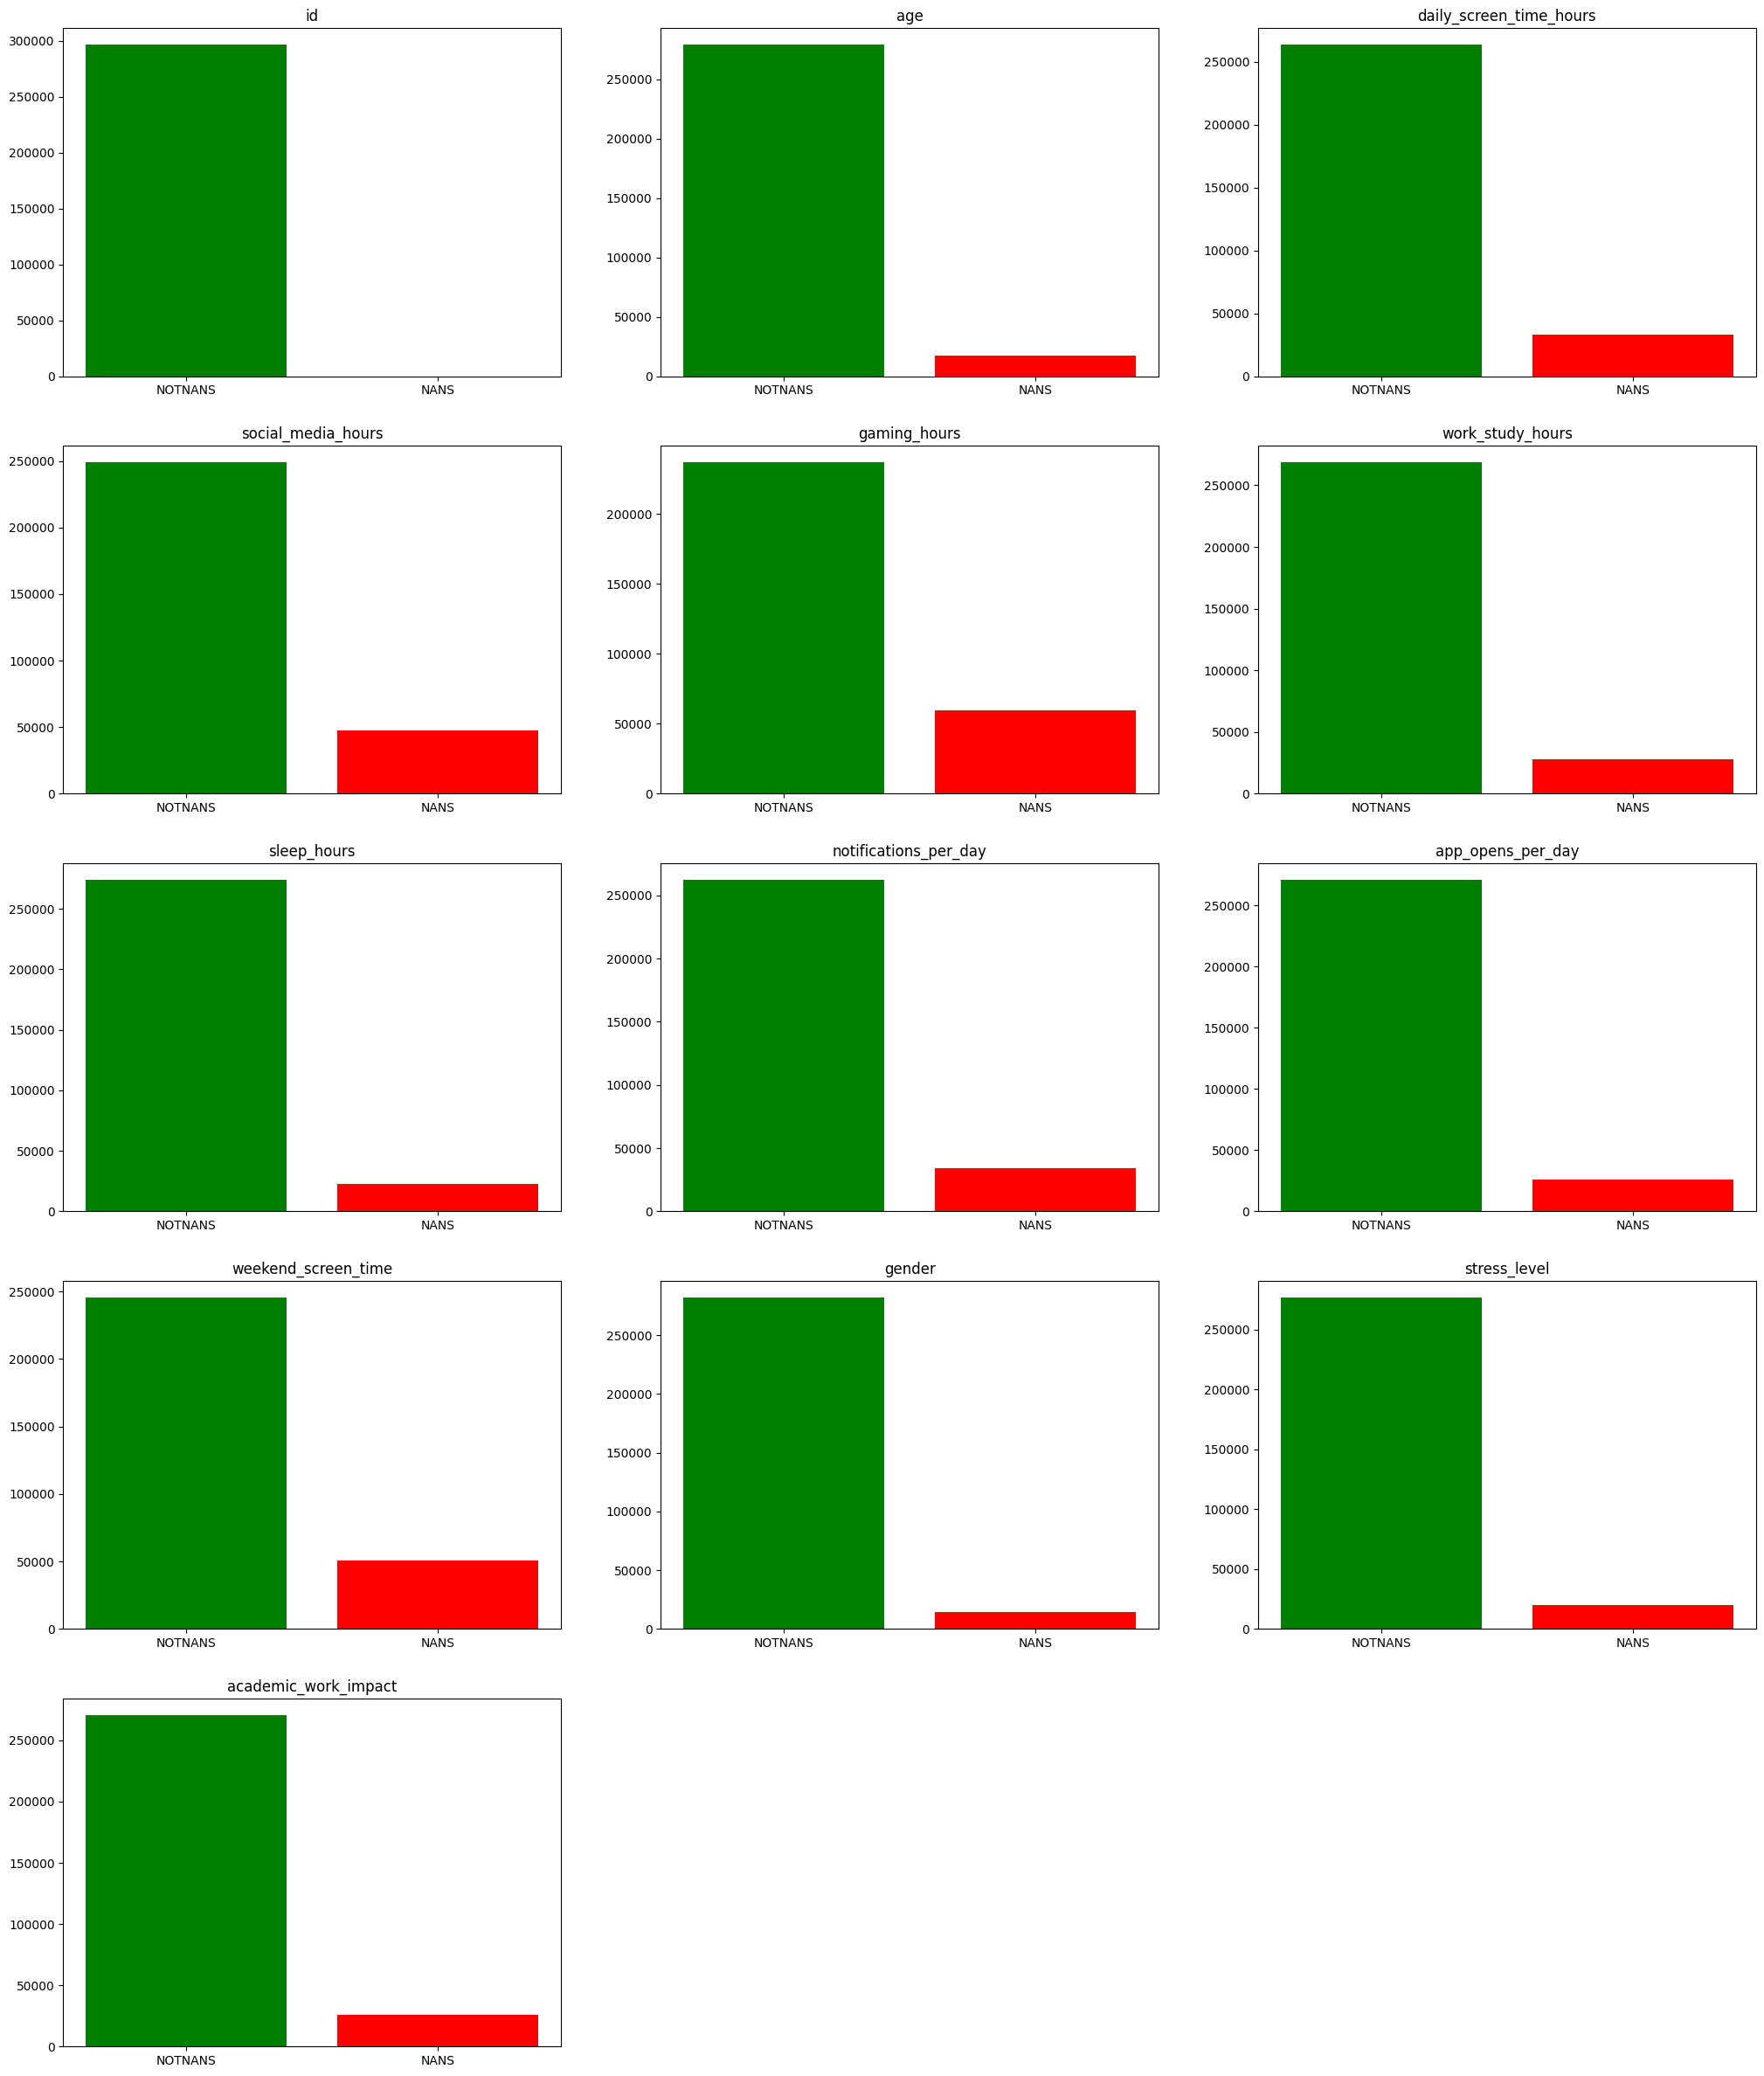

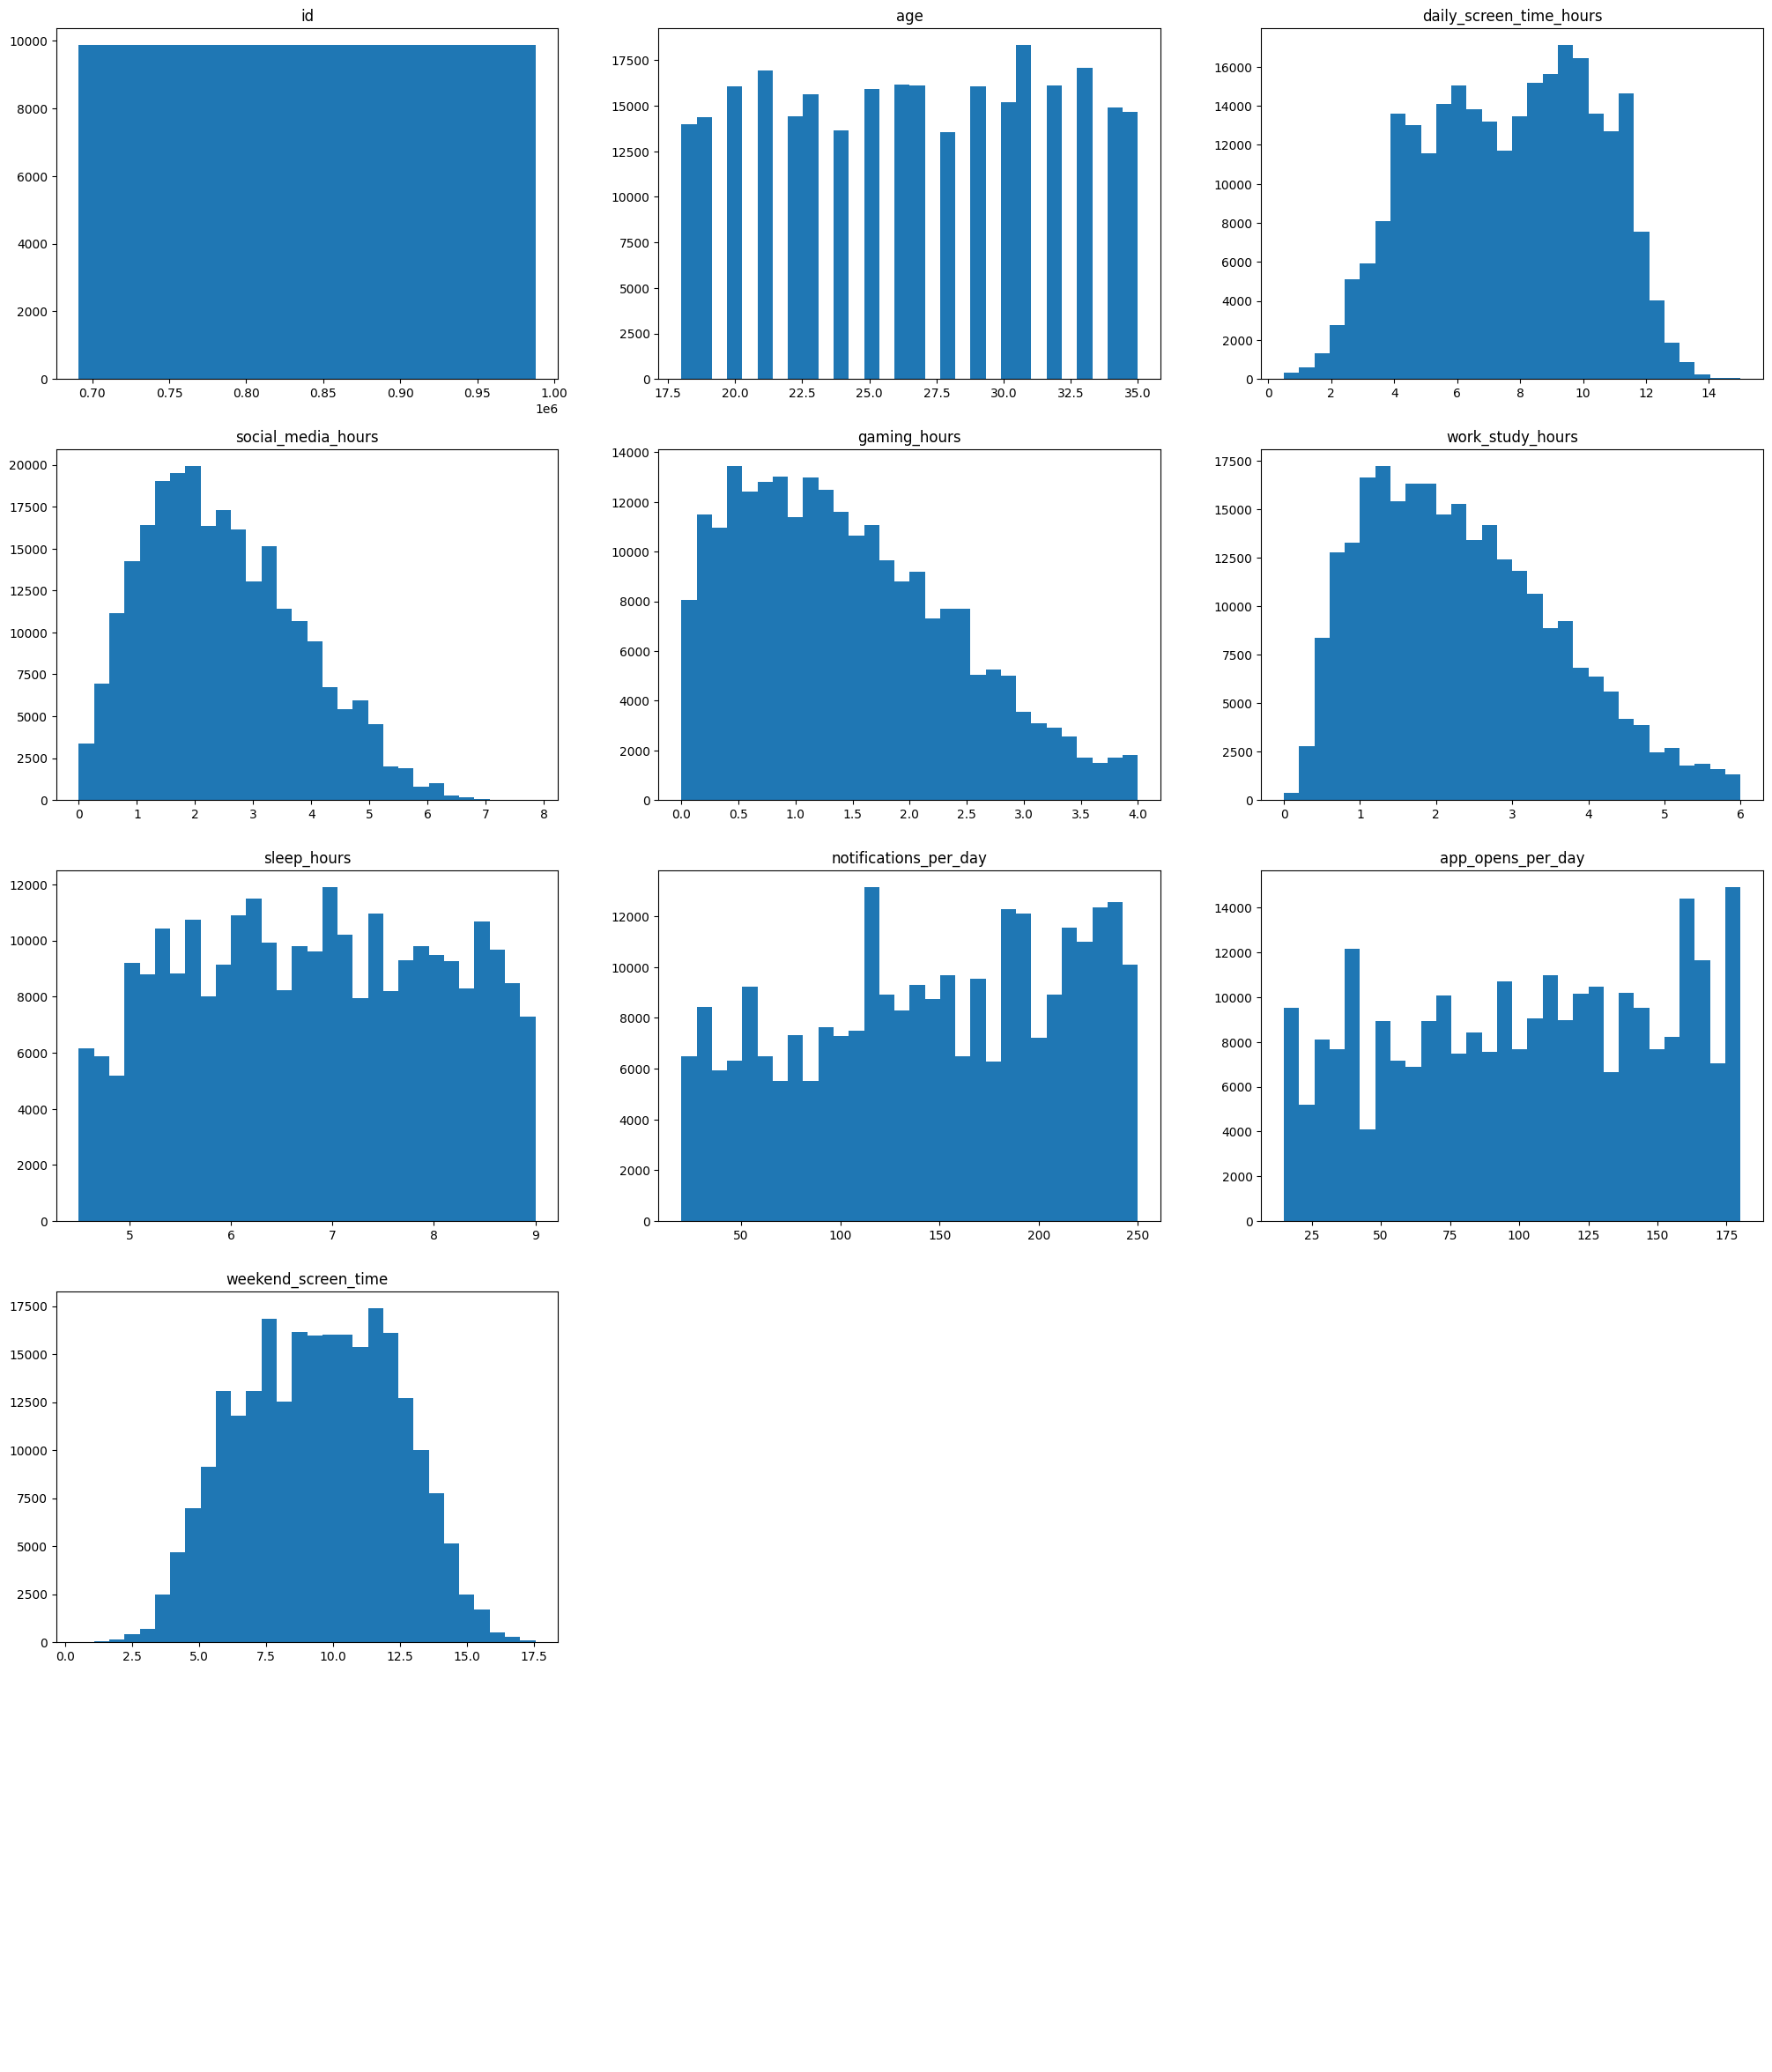

SUBMITTED TO /Users/almazbaktygali/Desktop/machine/playgroundseries_tasks/6s8/data/sample_submission.csv


In [47]:
model = train(train_csv)
predict(test_csv, model)
